In [137]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import json
import numpy as np
import math

log_name = 'local_goals_2'
other_log_name = 'long_goals_1'

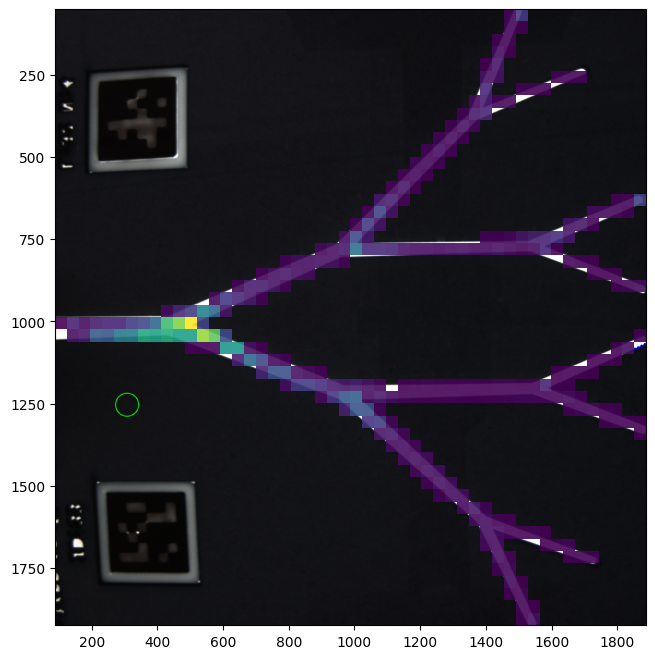

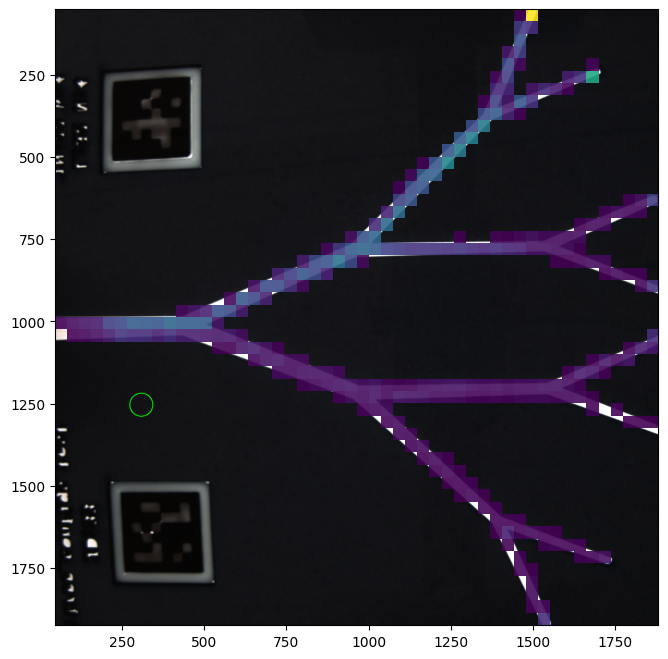

In [138]:
def get_heatmap(log_name):
    x_coords = []
    y_coords = []

    with open(f'catheter_log_{log_name}.jsonl', 'r') as f:
        for i, line in enumerate(f):
            data = json.loads(line)
            x_coords.append(data['tip_xy'][0])
            y_coords.append(data['tip_xy'][1]) 

    fig, ax = plt.subplots(figsize=(10, 8))

    img = mpimg.imread('../src/background.png')
    h, w = img.shape[:2]

    ax.imshow(img, extent=[0, w, h, 0], aspect='auto')

    heatmap, xedges, yedges = np.histogram2d(x_coords, y_coords, bins=50)

    heatmap[heatmap == 0] = np.nan

    ax.imshow(heatmap.T, extent=[xedges[0], xedges[-1], yedges[-1], yedges[0]], alpha=0.9, vmin=0)


    plt.savefig(f'exploration_heatmap_{log_name}.png', dpi=300)
    plt.show()

get_heatmap(log_name)

if other_log_name:
    get_heatmap(other_log_name)

In [144]:
precomputed_goals = [
    [(269, 1019), (383, 1015), (466, 1004), (549, 973), (623, 934), (691, 907), (770, 875), (842, 839), (933, 801), (1024, 739), (1081, 682), (1122, 638), (1170, 591), (1226, 536), (1287, 466), (1340, 413), (1376, 373), (1395, 328), (1412, 292), (1431, 243), (1463, 186), (1484, 137), (1491, 108), (1506, 63)],
    [(301, 1032), (403, 1015), (477, 1017), (540, 1049), (617, 1083), (683, 1113), (748, 1140), (801, 1161), (873, 1178), (924, 1197), (986, 1221), (1050, 1214), (1117, 1212), (1164, 1221), (1268, 1214), (1353, 1216), (1431, 1216), (1491, 1212), (1563, 1208), (1629, 1180), (1692, 1151), (1752, 1125), (1807, 1102), (1851, 1081), (1890, 1064)],
    [(273, 1026), (379, 1015), (470, 1004), (543, 977), (627, 928), (712, 903), (791, 867), (848, 841), (931, 809), (1011, 752), (1058, 697), (1094, 659), (1134, 619), (1187, 566), (1249, 504), (1294, 457), (1332, 419), (1376, 377), (1431, 362), (1482, 341), (1529, 318), (1576, 298), (1637, 273), (1701, 248)], 
    [(284, 1011), (364, 1028), (428, 1019), (502, 1015), (528, 1051), (576, 1074), (642, 1098), (702, 1113), (761, 1136), (801, 1153), (850, 1174), (899, 1180), (960, 1208), (1016, 1225), (1067, 1223), (1141, 1221), (1207, 1223), (1289, 1221), (1357, 1219), (1412, 1223), (1440, 1221), (1497, 1210), (1550, 1208), (1599, 1227), (1644, 1242), (1684, 1261), (1739, 1280), (1788, 1295), (1832, 1312), (1894, 1333)],
    [(256, 1019), (350, 1007), (458, 1009), (566, 968), (636, 930), (725, 892), (791, 862), (871, 828), (952, 790), (1018, 786), (1079, 786), (1143, 786), (1217, 784), (1289, 784), (1357, 786), (1412, 778), (1465, 775), (1514, 773), (1561, 771), (1599, 754), (1644, 729), (1697, 712), (1754, 689), (1809, 667), (1851, 644), (1877, 638)],
    [(238, 1012), (335, 1004), (381, 1014), (447, 1021), (447, 1021), (517, 1037), (574, 1057), (629, 1078), (692, 1110), (759, 1131), (812, 1157), (876, 1182), (950, 1205), (993, 1223), (1021, 1253), (1060, 1299), (1102, 1332), (1145, 1375), (1196, 1415), (1246, 1459), (1300, 1511), (1348, 1553), (1380, 1581), (1403, 1597), (1518, 1645), (1578, 1666), (1629, 1685), (1686, 1701), (1719, 1728)],
    [(250, 1030), (345, 1024), (458, 1011), (553, 981), (627, 937), (708, 892), (774, 856), (859, 839), (965, 801), (1026, 792), (1081, 786), (1145, 784), (1232, 788), (1291, 782), (1342, 784), (1393, 773), (1465, 778), (1520, 773), (1563, 773), (1593, 788), (1629, 807), (1669, 826), (1714, 841), (1769, 860), (1824, 884), (1883, 905)],
    [(292, 1024), (360, 1024), (449, 1026), (513, 1043), (572, 1074), (621, 1089), (661, 1104), (723, 1130), (784, 1149), (835, 1174), (893, 1197), (943, 1214), (999, 1238), (1047, 1282), (1073, 1310), (1111, 1337), (1145, 1375), (1181, 1407), (1228, 1450), (1289, 1494), (1327, 1530), (1364, 1566), (1419, 1649), (1442, 1693), (1465, 1740), (1482, 1780), (1504, 1819), (1552, 1918)]
]

# easy way to generate long horizon goals
long_horizon_goals = [list(x[-1]) for x in precomputed_goals]


def get_subgoals_for_long_horizon(log_name):
    subgoals_reached_per_ep = []
    with open(f'catheter_log_{log_name}.jsonl', 'r') as f:
        subgoals = None
        subgoal_idx = 0
        for i, line in enumerate(f):
            try:
                data = json.loads(line)
            except:
                print(line)
                continue
            tip_xy = data['tip_xy']

            if data['truncated'] or data['terminated']:
                subgoals = None
                subgoals_reached_per_ep.append(subgoal_idx)
                subgoal_idx = 0
                continue

            if subgoals is None:
                long_goal = [int(data['goal_xy'][0]), int(data['goal_xy'][1])]
                subgoals = precomputed_goals[long_horizon_goals.index(long_goal)]

            distances = [math.dist(tip_xy, sg) for sg in subgoals]

            reached_indices = [i for i, d in enumerate(distances) if d < 45]
            if reached_indices:
                max_reached = max(reached_indices)

                subgoal_idx = max(max_reached, subgoal_idx)
    return subgoals_reached_per_ep

{"step": 47, "tip_xy": [1467.0, 323.0]            

, "goal_xy": [1877.0, 638.0], "dist_px": 517.0347900390625, "ins_rel_cm": -0.2726123332977295, "rot_rel_rad": 0.5015483498573303, "state": {"insertion_cm": 19.187165319919586, "rotation_rad": 0.5015483498573303, "insertion_units": 9593.582659959793, "rotation_units": 211.53333256035017}, "motion_ok": true, "reward": -0.09756905233391566, "terminated": false, "truncated": false}



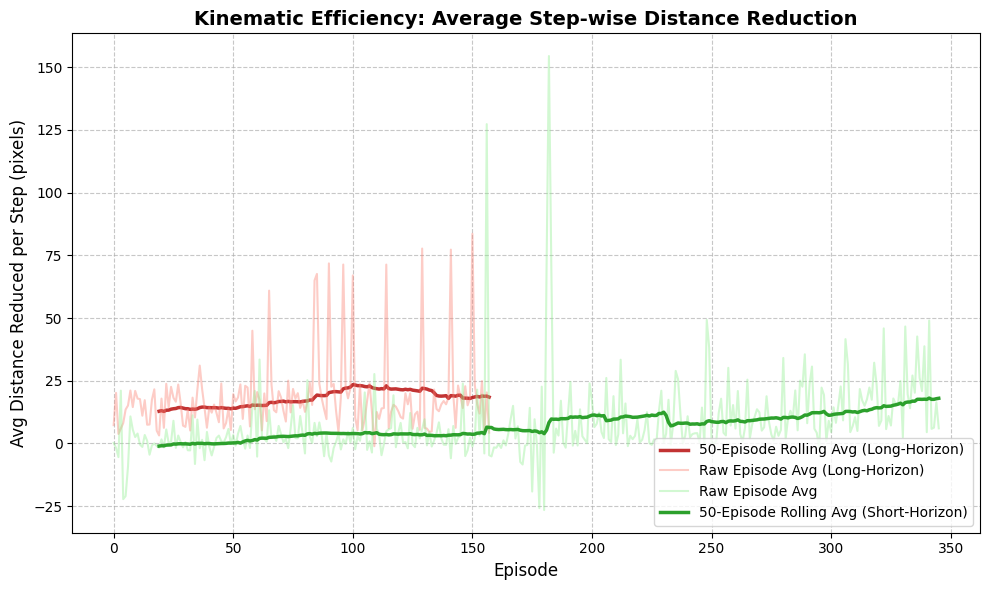

In [142]:
def get_data(log_name):
    episodes = []
    current_episode = []

    with open(f'catheter_log_{log_name}.jsonl', 'r') as f:
        for line in f:
            try:
                data = json.loads(line)
            except:
                print(line)
            current_episode.append(data)
            if data.get('terminated') or data.get('truncated') or data.get('step') == 60:
                episodes.append(current_episode)
                current_episode = []

    avg_step_reductions = []
    subgoals_reached_per_ep = []

    for ep in episodes:
        if len(ep) < 2:
            continue
            
        step_reductions = []
        goal_shifts = 0
        
        for i in range(1, len(ep) - 1):
            prev_goal = ep[i-1]['goal_xy']
            curr_goal = ep[i]['goal_xy']
            
            goal_moved = math.dist(prev_goal, curr_goal) > 0.1
            
            if goal_moved:
                goal_shifts += 1
                step_reductions.append(prev_dist)
                continue
                
            prev_dist = ep[i-1]['dist_px']
            curr_dist = ep[i]['dist_px']
            
            reduction = prev_dist - curr_dist 
            step_reductions.append(reduction)

        subgoals_reached_per_ep.append(goal_shifts)
            
        if len(step_reductions) > 0:
            avg_step_reductions.append(np.mean(step_reductions))
        else:
            avg_step_reductions.append(0)

    return avg_step_reductions, subgoals_reached_per_ep

avg_step_reductions, subgoals_reached_per_ep = get_data(log_name)

window_size = 50 
smoothed_reductions = pd.Series(avg_step_reductions).rolling(window=window_size, min_periods=20).mean()

# 4. Plot the data
plt.figure(figsize=(10, 6))

# Plot a dashed line at Y=0. 
# Anything below this line means the robot is failing/moving backwards.
# plt.axhline(y=0, color='black', linestyle='--', alpha=0.5, label='Zero Progress Baseline')

if other_log_name:
    other_avg_reductions, other_subgoals_reached_per_ep = get_data(other_log_name)
    other_smoothed = pd.Series(other_avg_reductions).rolling(window=window_size, min_periods=20).mean()
    plt.plot(other_smoothed, color="#b30000", linewidth=2.5, alpha=0.8, label='50-Episode Rolling Avg (Long-Horizon)')
    plt.plot(other_avg_reductions, color='salmon', alpha=0.4, label='Raw Episode Avg (Long-Horizon)')

# Raw data in the background
plt.plot(avg_step_reductions, color='lightgreen', alpha=0.4, label='Raw Episode Avg')

plt.plot(smoothed_reductions, color='#2ca02c', linewidth=2.5, label='50-Episode Rolling Avg (Short-Horizon)')



plt.title('Kinematic Efficiency: Average Step-wise Distance Reduction', fontsize=14, fontweight='bold')
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Avg Distance Reduced per Step (pixels)', fontsize=12)
plt.legend(loc='lower right', frameon=True)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig(f'kinematic_efficiency_{log_name}.png', dpi=300)
plt.show()

{"step": 47, "tip_xy": [1467.0, 323.0]            

, "goal_xy": [1877.0, 638.0], "dist_px": 517.0347900390625, "ins_rel_cm": -0.2726123332977295, "rot_rel_rad": 0.5015483498573303, "state": {"insertion_cm": 19.187165319919586, "rotation_rad": 0.5015483498573303, "insertion_units": 9593.582659959793, "rotation_units": 211.53333256035017}, "motion_ok": true, "reward": -0.09756905233391566, "terminated": false, "truncated": false}



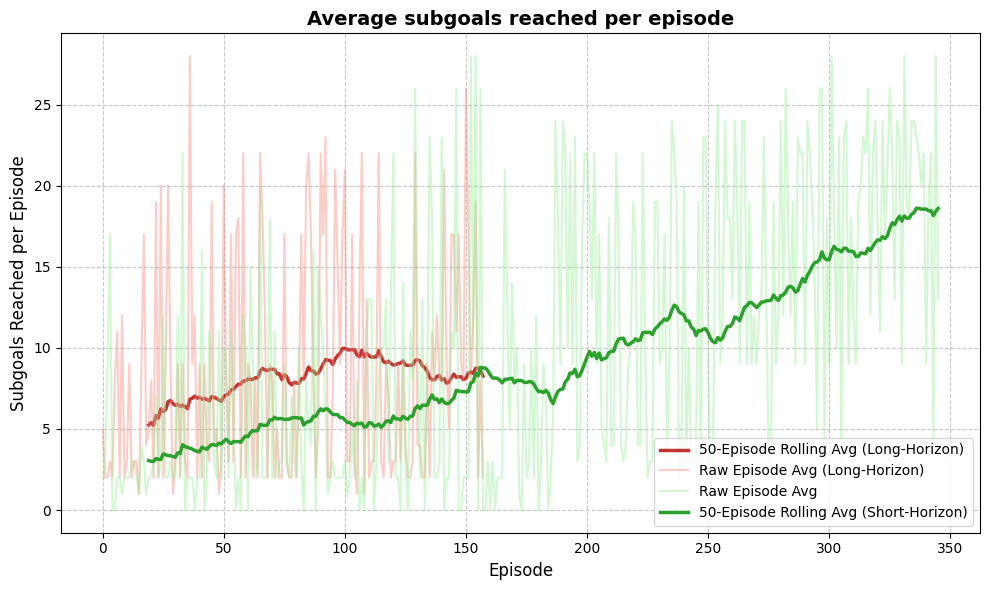

In [145]:
smoothed_reductions = pd.Series(subgoals_reached_per_ep).rolling(window=window_size, min_periods=20).mean()

# 4. Plot the data
plt.figure(figsize=(10, 6))

# Plot a dashed line at Y=0. 
# Anything below this line means the robot is failing/moving backwards.
# plt.axhline(y=0, color='black', linestyle='--', alpha=0.5, label='Zero Progress Baseline')


if other_log_name:
    # other_avg_reductions, other_subgoals_reached_per_ep = get_data(other_log_name)
    other_subgoals_reached_per_ep = get_subgoals_for_long_horizon(other_log_name)
    other_smoothed = pd.Series(other_subgoals_reached_per_ep).rolling(window=window_size, min_periods=20).mean()
    plt.plot(other_smoothed, color="#b30000", linewidth=2.5, alpha=0.8, label='50-Episode Rolling Avg (Long-Horizon)')
    plt.plot(other_subgoals_reached_per_ep, color='salmon', alpha=0.4, label='Raw Episode Avg (Long-Horizon)')

# Raw data in the background
plt.plot(subgoals_reached_per_ep, color='lightgreen', alpha=0.4, label='Raw Episode Avg')

# Smoothed trendline
plt.plot(smoothed_reductions, color='#2ca02c', linewidth=2.5, label='50-Episode Rolling Avg (Short-Horizon)')

plt.title('Average subgoals reached per episode', fontsize=14, fontweight='bold')
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Subgoals Reached per Episode', fontsize=12)
plt.legend(loc='lower right', frameon=True)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig(f'kinematic_efficiency_{log_name}.png', dpi=300)
plt.show()

{"step": 47, "tip_xy": [1467.0, 323.0]            

, "goal_xy": [1877.0, 638.0], "dist_px": 517.0347900390625, "ins_rel_cm": -0.2726123332977295, "rot_rel_rad": 0.5015483498573303, "state": {"insertion_cm": 19.187165319919586, "rotation_rad": 0.5015483498573303, "insertion_units": 9593.582659959793, "rotation_units": 211.53333256035017}, "motion_ok": true, "reward": -0.09756905233391566, "terminated": false, "truncated": false}



/tmp/ipykernel_328832/435265346.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


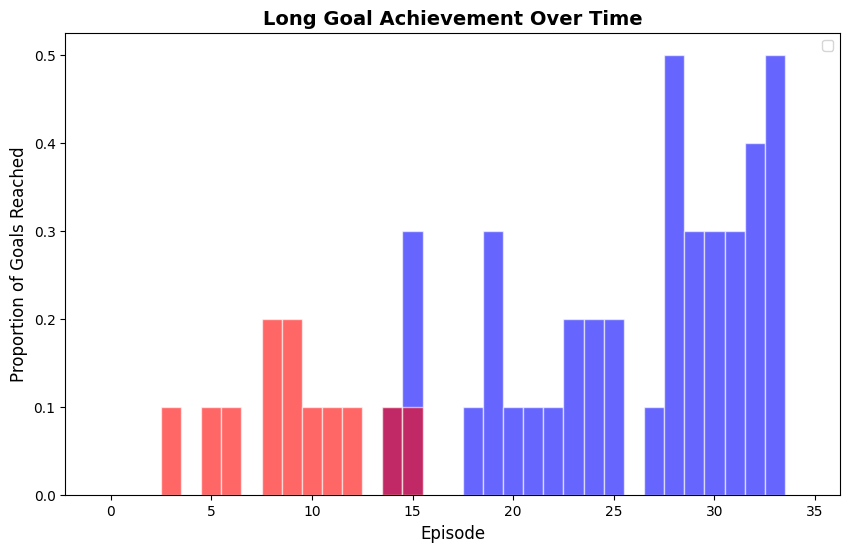

In [149]:
def long_goals_over_time(log_name, chunk_size=10):
    goals_over_time = []
    with open(f'catheter_log_{log_name}.jsonl', 'r') as f:
        for line in f:
            try:
                data = json.loads(line)
            except:
                print(line)
                continue
            if data.get('terminated'):
                goals_over_time.append(1)
            elif data.get('truncated'):
                goals_over_time.append(0)

    counts = [np.sum(goals_over_time[i:i+chunk_size]) / chunk_size for i in range(0, len(goals_over_time), chunk_size)]
    return counts

binned_goals = long_goals_over_time(log_name, chunk_size=10)
other_binned_goals = long_goals_over_time(other_log_name, chunk_size=10) if other_log_name else None

# goals_over_time_binned = np.histogram(goals_over_time, bins=10)[0]

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(range(len(binned_goals)), binned_goals, width=1.0, edgecolor='white', color='blue', alpha=0.6)
if other_binned_goals is not None:
    ax.bar(range(len(other_binned_goals)), other_binned_goals, width=1.0, edgecolor='white', color='red', alpha=0.6)
plt.title('Long Goal Achievement Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Proportion of Goals Reached', fontsize=12)
plt.legend(loc='upper right')
plt.show()

In [51]:
from pathlib import Path
from PIL import Image

def make_gif_from_folder(folder_path, output_filename=None, frame_duration=200, loop_count=0):
    image_files = sorted(Path(folder_path).glob('step_*.png'))  # Adjust the pattern if your frames have a different extension
    
    frames = []
    for img_file in image_files:
        img = Image.open(img_file)

        if img.mode != 'RGB':
            img = img.convert('RGB')
        
        img.thumbnail((400, 400))

        frames.append(img)

    if output_filename is None:
        output_filename = f'{folder_path}.gif'

    frames[0].save(
        output_filename,
        save_all=True,
        append_images=frames[1:],
        duration=frame_duration,
        loop=loop_count
    )

make_gif_from_folder('../training_videos_local_goals_2/episode_0225', 'episode_0225.gif')

In [89]:
# import os, pathlib, glob, shutil

# # append the episodes from local goals 3 into the list from 2.

# local_goals_3_episodes = os.listdir('../training_videos')
# local_goals_3_episodes.sort()

# for ep in local_goals_3_episodes:
#     new_episode_index = int(ep.split('_')[1]) + 170
#     shutil.copytree(os.path.join('../training_videos', ep), os.path.join('../training_videos_local_goals_2', f'episode_0{new_episode_index}'))